## 🏦 Financial Fraud Risk Assessment Using Transaction Behavior Analysis and Statistical Insights


# 1. Project Introduction

## Problem Statement :

Financial fraud has become one of the biggest challenges in the banking industry. Fraudulent transactions can lead to major financial losses for banks and customers. Detecting fraud manually is difficult because banking systems process millions of transactions every day. The main challenge is identifying fraudulent transactions accurately while minimizing false alarms. This project focuses on analyzing banking transaction data to detect fraud patterns and understand the key factors that contribute to fraudulent activities.

## Dataset Overview :

This project uses a synthetic banking transaction dataset containing 1,000,000 transactions generated from multiple countries between 2020 and 2024. The dataset includes 26 columns related to customer information, transaction behavior, payment methods, device types, account details, and fraud indicators. Around 5.5% of the transactions are labeled as fraudulent, making the dataset realistic for fraud detection analysis and imbalanced classification problems.

## Goal of Fraud Detection :

The primary goal of this project is to analyze transaction patterns and build a fraud detection system capable of identifying suspicious transactions. The project aims to:

* Discover important fraud trends and risk factors
* Perform exploratory and statistical analysis
* Identify high-risk transaction behaviors
* Build machine learning models for fraud prediction
* Evaluate model performance using classification metrics
* Generate business insights that can help reduce financial fraud


# 2. Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm 
from matplotlib.ticker import FuncFormatter
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from warnings import filterwarnings
filterwarnings('ignore')

# Set Color Theme 

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
custom_palette  = viridis_colors
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
natural_color = viridis_colors[3]
denger_color = '#D10000'

# 3. Load Dataset

In [3]:
df = pd.read_csv('banking_fraud_dataset.csv')

In [4]:
df.sample(5)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
766985,TXN0000766986,CUST00096939,2023-04-24,02:23:00,2,0,1,USA,São Paulo,Gaming,...,19.16,151,14,13.7,22.18,0,0,0,0,NaN
483933,TXN0000483934,CUST00047626,2022-08-05,22:44:00,22,0,1,USA,Vancouver,Electronics,...,334.22,175,20,17.2,10.59,0,0,0,0,NaN
743609,TXN0000743610,CUST00054072,2022-09-14,11:24:00,11,0,0,Brazil,Lyon,Restaurant,...,29.38,171,23,15.4,15.57,0,0,0,0,NaN
818716,TXN0000818717,CUST00079776,2024-06-14,15:09:00,15,0,0,Japan,Toronto,Fuel,...,147.26,145,17,12.4,3.42,0,0,0,0,NaN
751489,TXN0000751490,CUST00012796,2022-10-18,18:39:00,18,0,0,India,Guadalajara,Online Shopping,...,37.99,149,15,30.1,2.80,0,2,0,1,Account Takeover


# 4. Data Understanding

In [5]:
print("Number of Rows: ", df.shape[0])
print("Number of Columns: ", df.shape[1])
print('\nAll Columns:',list(df.columns))

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print('\nNumber of Numerical Columns:', len(numeric_cols))

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print('Number of Categorical Columns:', len(categorical_cols))

datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns
print('Number of Date/Time Columns:', len(datetime_cols))

print('\nAll Columns Information:\n')
df.info()

print('\nChack Duplicate Records:',df.duplicated().sum())
print('\nChack Missing Values:')
df.isnull().sum().sort_values(ascending=False)

Number of Rows:  1000000
Number of Columns:  26

All Columns: ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type']

Number of Numerical Columns: 16
Number of Categorical Columns: 10
Number of Date/Time Columns: 0

All Columns Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non

fraud_type                  944745
transaction_id                   0
transaction_date                 0
transaction_time                 0
hour_of_day                      0
is_weekend                       0
is_night_transaction             0
country                          0
city                             0
customer_id                      0
merchant_category                0
payment_method                   0
customer_age                     0
device_type                      0
account_age_years                0
account_balance                  0
transaction_amount               0
credit_score                     0
num_prev_transactions            0
transaction_freq_monthly         0
time_since_last_txn_hrs          0
distance_from_home_km            0
is_international                 0
failed_attempts                  0
pin_changed_recently             0
is_fraud                         0
dtype: int64

In [6]:
# Statistical Summary
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.25442,204.724665,149.996350,19.999322,20.009890,12.000945,0.149994,0.380072,0.080439,0.055255
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.46068,459.567802,12.244379,4.474045,20.011427,11.999904,0.357066,0.914603,0.271972,0.228477
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.00000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.01750,33.400000,142.000000,17.000000,5.800000,3.450000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.12000,73.120000,150.000000,20.000000,13.900000,8.320000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.02500,181.450000,158.000000,23.000000,27.700000,16.630000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.00000,46129.600000,213.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


# 5. Data Cleaning and Preparation

In [7]:
# Handle Missing Values
df['fraud_type']= df['fraud_type'].fillna('No Fraud')
df['fraud_type'].value_counts()

# Date and Time Conversion 
df['transaction_date'] = df['transaction_date'].astype('datetime64[ns]')
df['transaction_time'] = df['transaction_time'].astype('datetime64[ns]')

def time_period(hour): 
    if 6 < hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour <= 21:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['hour_of_day'].apply(time_period)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print('\nNumber of Numerical Columns:', len(numeric_cols))
print('Columns:\n',numeric_cols.to_list())

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print('\nNumber of Categorical Columns:', len(categorical_cols))
print('Columns:\n',categorical_cols.to_list())

datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns
print('\nNumber of Date/Time Columns:', len(datetime_cols))
print('Columns:\n',datetime_cols.to_list())

print('\nNumber of Duplicate Records:',df.duplicated().sum()) 
print('\nNumber of Missing values:')
df.isnull().sum()


Number of Numerical Columns: 16
Columns:
 ['hour_of_day', 'is_weekend', 'is_night_transaction', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud']

Number of Categorical Columns: 9
Columns:
 ['transaction_id', 'customer_id', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'fraud_type', 'time_period']

Number of Date/Time Columns: 2
Columns:
 ['transaction_date', 'transaction_time']

Number of Duplicate Records: 0

Number of Missing values:


transaction_id              0
customer_id                 0
transaction_date            0
transaction_time            0
hour_of_day                 0
is_weekend                  0
is_night_transaction        0
country                     0
city                        0
merchant_category           0
payment_method              0
device_type                 0
customer_age                0
credit_score                0
account_age_years           0
account_balance             0
transaction_amount          0
num_prev_transactions       0
transaction_freq_monthly    0
distance_from_home_km       0
time_since_last_txn_hrs     0
is_international            0
failed_attempts             0
pin_changed_recently        0
is_fraud                    0
fraud_type                  0
time_period                 0
dtype: int64

# 6. Exploratory Data Analysis (EDA)

In [8]:
# Function to Format Large Numbers into K and M Notation
def format_func(value):
    if value >= 1e6: 
        return f'{value/1e6:.0f}M'
    elif value >= 1e3: 
        return f'{value/1e3:.0f}K'
    else:
        return f'{value:.0f}'

## >> 6.1 Dataset Overview KPIs

In [9]:
print('------ Business KPIs ------\n')

print('Total Transactions:',len(df))
print('Total Unique Customers:', df['customer_id'].nunique())
print("Fraud Transactions:",df['is_fraud'].sum())
fraud_rate = (df['is_fraud'].sum() / len(df)) * 100
print(f"Fraud Rate: {fraud_rate:.2f}%")
print('Total Countries:', df['country'].nunique())
print('Total Cities:', df['city'].nunique())
print('Total Merchant Categories:', df['merchant_category'].nunique())
print('Total Payment Methods:', df['payment_method'].nunique())
print('Average Transaction Amount', df['transaction_amount'].mean())

------ Business KPIs ------

Total Transactions: 1000000
Total Unique Customers: 198662
Fraud Transactions: 55255
Fraud Rate: 5.53%
Total Countries: 10
Total Cities: 20
Total Merchant Categories: 15
Total Payment Methods: 6
Average Transaction Amount 204.72466542


## >> 6.2 Transaction Analysis

### 1. Transaction Amount Distribution


Amount Summary:



,Amount Category,Transaction Count,Percentage
0,Very Low Amount,597794,59.78
1,Low Amount,308676,30.87
2,Medium Amount,55810,5.58
3,High Amount,37610,3.76
4,Very High Amount,110,0.01


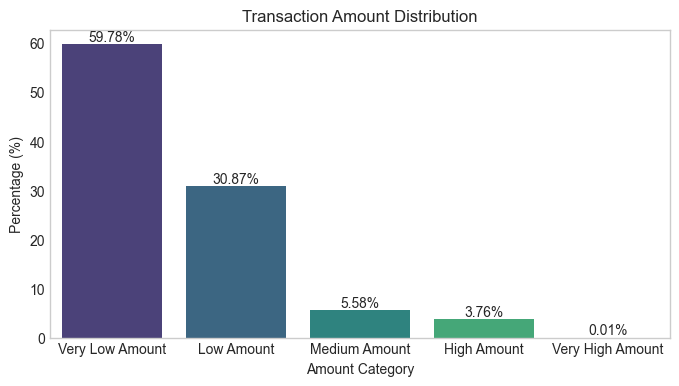

In [10]:
def amount_cat(amount):
    if 1 <= amount <= 100: 
        return 'Very Low Amount'
    elif 100 < amount <= 500:
        return 'Low Amount'
    elif 500 < amount <= 1000: 
        return 'Medium Amount'
    elif 1000 < amount <= 10000: 
        return 'High Amount'
    else: 
        return 'Very High Amount'
# Function call
df['amount_category'] = df['transaction_amount'].apply(amount_cat)

temp = df['amount_category'].value_counts()
percentage = df['amount_category'].value_counts(normalize=True)*100

amount_summary = pd.DataFrame({
    'Amount Category' : temp.index, 
    'Transaction Count' : temp.values,
    'Percentage' : percentage.values.round(2)
})
print('\nAmount Summary:\n')
display(amount_summary)

plt.figure(figsize=(8,4))
ax = sns.barplot(data=amount_summary, x='Amount Category', y='Percentage', palette='viridis')

for container in ax.containers: 
    ax.bar_label(container, fmt='%.2f%%')

ax.grid(False)
plt.title('Transaction Amount Distribution')
plt.ylabel('Percentage (%)')
plt.show()

### 2. Transaction Trend Over Time

In [11]:
print('------ Yearly Transaction Details ------\n')
years = df['transaction_date'].dt.year.value_counts().reset_index()
years.columns = ['Years', 'Total_Transaction']
years['Percentage'] = (years['Total_Transaction'] / years['Total_Transaction'].sum() * 100).round(2)
display(years)

print('\n------ Monthly Transaction Details ------\n')
months = df['transaction_date'].dt.month_name().value_counts().reset_index()
months.columns = ['Months', 'Total_Transaction']
months['Percentage'] = (months['Total_Transaction'] / months['Total_Transaction'].sum() * 100).round(2)
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
months = months.set_index('Months').loc[month_order].reset_index()
display(months)

print('\n------ Transaction Activity by Time Period ------\n')
time_period = df['time_period'].value_counts().reset_index()
time_period.columns = ['Time Period','Total_Transaction']
time_period['Percentage'] = (time_period['Total_Transaction'] / time_period['Total_Transaction'].sum() * 100).round(2)
display(time_period)

------ Yearly Transaction Details ------



,Years,Total_Transaction,Percentage
0,2020,201016,20.10
1,2022,200635,20.06
2,2023,199673,19.97
3,2021,199351,19.94
4,2024,199325,19.93



------ Monthly Transaction Details ------



,Months,Total_Transaction,Percentage
0,January,85493,8.55
1,February,77550,7.75
2,March,84796,8.48
3,April,82107,8.21
4,May,84660,8.47
5,June,81936,8.19
6,July,84872,8.49
7,August,84918,8.49
8,September,82352,8.24
9,October,85213,8.52



------ Transaction Activity by Time Period ------



,Time Period,Total_Transaction,Percentage
0,Night,375057,37.51
1,Evening,209087,20.91
2,Morning,208173,20.82
3,Afternoon,207683,20.77


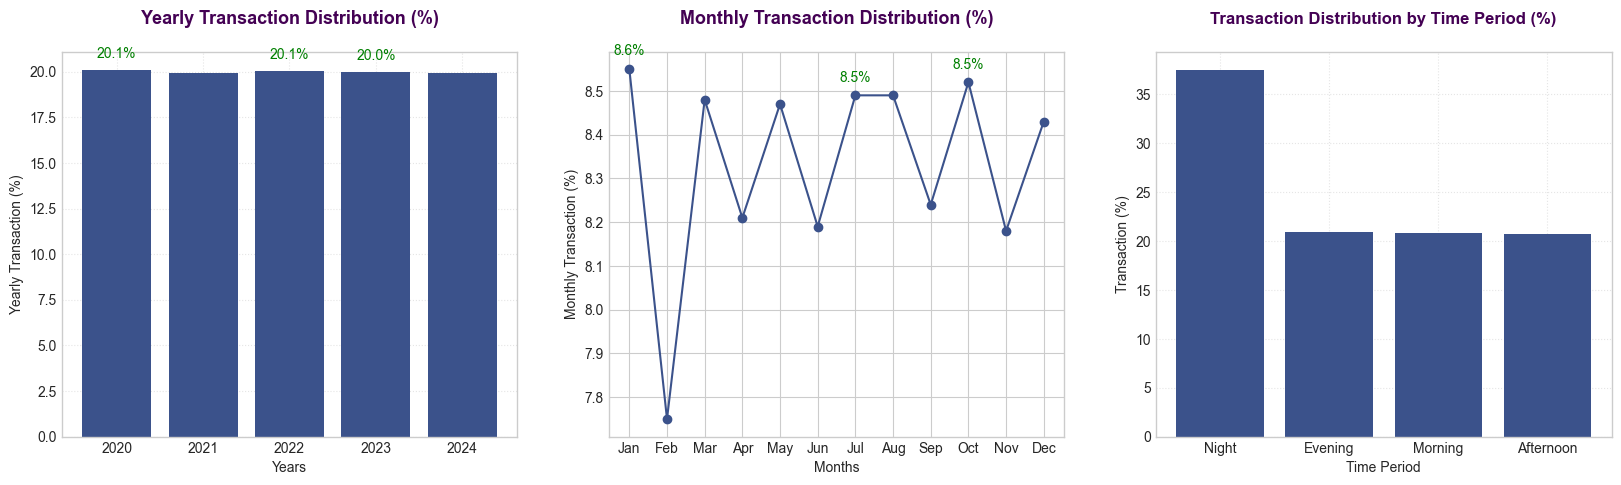

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,5))

# Subplot 1: Yearly Transaction Distribution (%) 
ax1.bar(years['Years'], years['Percentage'], color=secondary_color)
ax1.set_xlabel('Years')
ax1.set_ylabel('Yearly Transaction (%)')
ax1.set_title('Yearly Transaction Distribution (%)', fontsize=13, fontweight='bold', pad=20, color=primary_color)
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars 
top3_year = years.nlargest(3, 'Percentage')
for _, row in top3_year.iterrows(): 
    height = row['Percentage']
    ax1.text(row['Years'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom',fontsize=10, color='green')

# Subplot 2:Monthly Transaction (%)
ax2.plot(months['Months'], months['Percentage'], marker='o', color=secondary_color)
ax2.set_xlabel('Months')
ax2.set_ylabel('Monthly Transaction (%)')
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax2.set_title('Monthly Transaction Distribution (%)', fontsize=13, fontweight='bold', pad=20, color=primary_color)


# Annotate top 3 highest bars 
top3_month = months.nlargest(3, 'Percentage')
for _, row in top3_month.iterrows(): 
    ax2.annotate(f"{row['Percentage']:.1f}%", (row['Months'], row['Percentage']), 
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=10, color='green')

# Subplot 3: Transaction Distribution by Time Period (%) 
ax3.bar(time_period['Time Period'], time_period['Percentage'], color=secondary_color)
ax3.set_xlabel('Time Period')
ax3.set_ylabel('Transaction (%)')
ax3.set_title('Transaction Distribution by Time Period (%)', fontsize=12, fontweight='bold', pad=20, color=primary_color)
ax3.grid(True, linestyle=':', alpha=0.5)

### 3. Weekend vs Weekday Transactions

,Type,Total_Transaction,Percentage
0,Weekday,713978,71.4
1,Weekend,286022,28.6


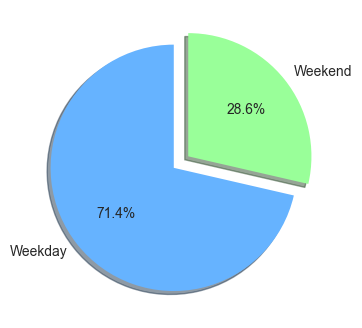

In [13]:
weekend = df['is_weekend'].value_counts().reset_index()
weekend.columns = ['Type', 'Total_Transaction']
weekend['Type'] = weekend['Type'].map({0:'Weekday', 1:'Weekend'})
weekend['Percentage'] = (weekend['Total_Transaction'] / weekend['Total_Transaction'].sum() * 100).round(2)
display(weekend)

plt.figure(figsize=(4,4))
plt.pie(weekend['Percentage'], labels=weekend['Type'],autopct='%1.1f%%', startangle=90, shadow=True, colors=['#66b3ff','#99ff99'],explode=(0.05, 0.1))
plt.show()

## >> 6.3 Fraud Pattern Analysis

### 1. Fraud by Transaction Amount Category + Average Fraud Amount

,amount_category,Fraud_Rate_Pct,Avg_Fraud_Amt
0,High Amount,6.35,2092.72
1,Low Amount,5.63,217.69
2,Medium Amount,5.93,699.12
3,Very High Amount,8.18,11991.70
4,Very Low Amount,5.38,43.50


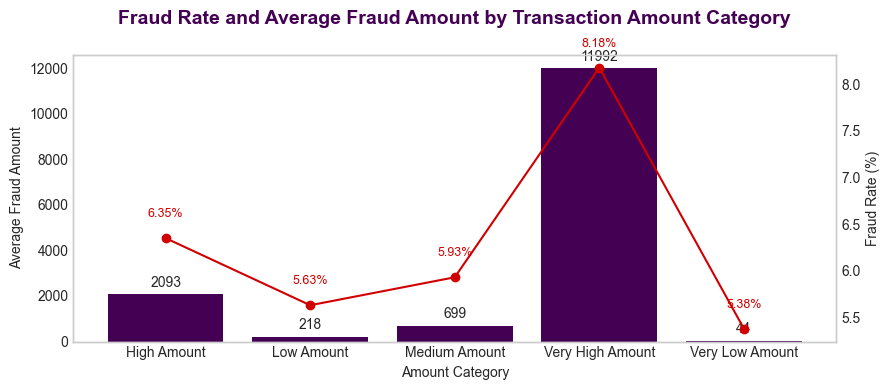

In [14]:
amount_analysis = df.groupby('amount_category').agg(
    Fraud_Rate_Pct = ('is_fraud', lambda x: round(x.mean() * 100, 2)),
    Avg_Fraud_Amt = ('transaction_amount',
                     lambda x: round(
                         df.loc[x.index]
                         .query('is_fraud == 1')['transaction_amount'].mean(),2
                     ))).reset_index()

display(amount_analysis)

# Create figure
fig, ax1 = plt.subplots(figsize=(9, 4))

# Bar Chart - Avg Fraud Amount
bars = ax1.bar(amount_analysis['amount_category'],amount_analysis['Avg_Fraud_Amt'], color=primary_color)
ax1.set_xlabel('Amount Category')
ax1.set_ylabel('Average Fraud Amount')
ax1.set_title('Fraud Rate and Average Fraud Amount by Transaction Amount Category',fontsize=14,fontweight='bold',pad=22, color=primary_color)
# Bar Labels
ax1.bar_label(bars,fmt='%.0f',padding=3)

# Second Axis - Fraud Rate %
ax2 = ax1.twinx()
ax2.plot(amount_analysis['amount_category'],amount_analysis['Fraud_Rate_Pct'],marker='o',linewidth=1.5, color=denger_color)
ax2.set_ylabel('Fraud Rate (%)')

# Line Labels
for x, y in zip(amount_analysis['amount_category'],amount_analysis['Fraud_Rate_Pct']):
    ax2.annotate(f'{y:.2f}%',(x, y),textcoords='offset points',xytext=(0, 15),ha='center',fontsize=9, color=denger_color)
    
ax1.grid(False)
ax2.grid(False)
plt.tight_layout()
plt.show()

### 2. Fraud by International vs Domestic Transactions

,is_international,Total_Transaction,Fraud_Transaction,Fraud_rate
0,Domestic,850006,40471,4.76
1,International,149994,14784,9.86


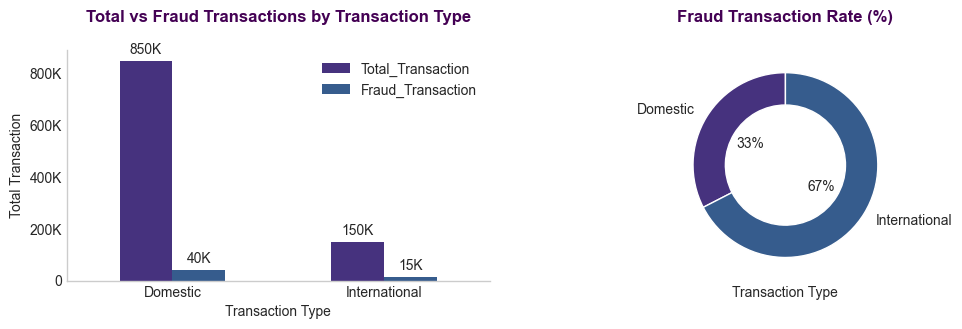

In [15]:
international_fraud = (df.groupby('is_international')['is_fraud'].agg(
    Total_Transaction = 'count', 
    Fraud_Transaction = 'sum',
    Fraud_rate = lambda x : round(x.mean()*100,2)
  ).reset_index()
)
international_fraud['is_international'] = international_fraud['is_international'].map({1:'International', 0:'Domestic'})
display(international_fraud)

print('\n')
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,3))

# Plot 1:
international_fraud.plot(x='is_international', y=['Total_Transaction', 'Fraud_Transaction'],kind='bar', ax=ax1)
for container in ax1.containers:
    labels = [format_func(v) for v in container.datavalues]
    ax1.bar_label(container, labels=labels, padding=3)

ax1.set_title('Total vs Fraud Transactions by Transaction Type', pad=20, color=primary_color, fontweight='bold')
ax1.set_xlabel('Transaction Type')
ax1.set_ylabel('Total Transaction')
ax1.tick_params(axis='x', rotation=0)
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: format_func(x)))

# plot 2:
ax2.pie(international_fraud['Fraud_rate'],labels=international_fraud['is_international'],autopct='%1.0f%%',startangle=90,pctdistance=0.45,
    labeldistance=1.15,wedgeprops={'width':0.35,'edgecolor':'white'})
ax2.set_title('Fraud Transaction Rate (%)',color=primary_color, fontsize=12, fontweight='bold', pad=20)
ax2.set_xlabel('Transaction Type')
plt.show()

### 3. Fraud by Failed Attempts

,failed_attempts,Total_transaction,Fraud_rate_pct,Avg_Transaction_amt
0,0,800037,4.52,204.58
1,1,99962,4.53,204.09
2,2,50038,14.60,206.72
3,3,29896,14.69,208.32
4,4,9989,14.38,203.50
5,5,10078,14.48,202.96


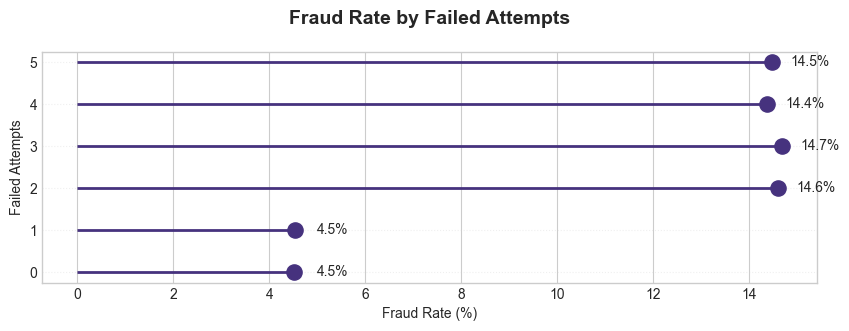

In [16]:
Failed_attempts = (df.groupby('failed_attempts').agg(
    Total_transaction = ('is_fraud','count'),
    Fraud_rate_pct = ('is_fraud', lambda x : round(x.mean()*100,2)),
    Avg_Transaction_amt = ('transaction_amount',lambda x: round(x.mean(), 2))
).reset_index())
display(Failed_attempts)

fig, ax = plt.subplots(figsize=(10,3))

# Stems
ax.hlines(y=Failed_attempts['failed_attempts'], xmin=0, xmax=Failed_attempts['Fraud_rate_pct'], linewidth=2)

# Dots
ax.scatter(Failed_attempts['Fraud_rate_pct'], Failed_attempts['failed_attempts'], s=120)

# Labels
for x, y in zip(Failed_attempts['Fraud_rate_pct'], Failed_attempts['failed_attempts']):
    ax.text(x + 0.8, y - 0.1, f'{x:.1f}%', ha='center')

ax.set_xlabel('Fraud Rate (%)')
ax.set_ylabel('Failed Attempts')
ax.set_title('Fraud Rate by Failed Attempts',fontsize=14 ,fontweight='bold',pad=20)
ax.grid(axis='y', linestyle=':', alpha=0.3)
plt.show()

### 4. Fraud by Time Since Last Transaction

,txn_gap_category,Total_transaction,Fraud_rate_pct
3,<1 Hour,79095,7.90
1,1-6 Hours,314337,5.38
2,7-24 Hours,471241,5.28
0,1-3 Days,132830,5.33
4,>3 Days,2497,5.09


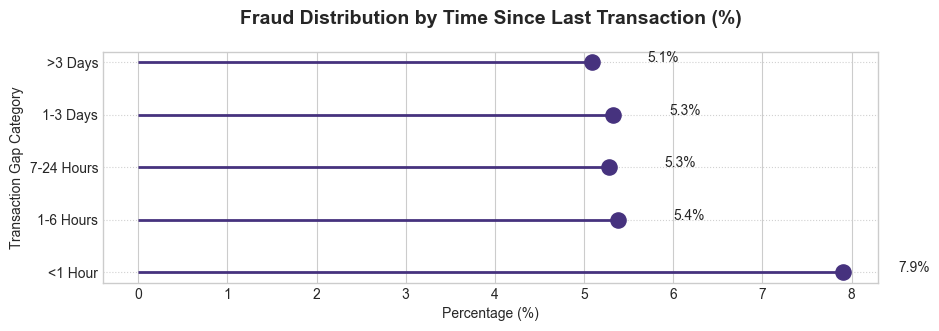

In [17]:
def transaction_gap(hour): 
    if hour < 1: 
        return '<1 Hour'
    elif  1 <= hour <= 6: 
        return '1-6 Hours'
    elif 6 < hour <= 24: 
        return '7-24 Hours'
    elif 24 < hour <= 72: 
        return '1-3 Days'
    else: 
        return '>3 Days'

df['txn_gap_category'] = df['time_since_last_txn_hrs'].apply(transaction_gap)

time_gap = (df.groupby('txn_gap_category').agg(
    Total_transaction = ('is_fraud', 'count'), 
    Fraud_rate_pct = ('is_fraud', lambda x : round(x.mean() * 100, 2))
).reset_index()) 

gap_order = ['<1 Hour','1-6 Hours','7-24 Hours','1-3 Days','>3 Days']
time_gap['txn_gap_category'] = pd.Categorical(time_gap['txn_gap_category'],categories=gap_order,ordered=True)
time_gap = time_gap.sort_values('txn_gap_category')
display(time_gap)

fig, ax = plt.subplots(figsize=(10,3))
# Stems
ax.hlines(y=time_gap['txn_gap_category'], xmin=0, xmax=time_gap['Fraud_rate_pct'], linewidth=2)

# Dots
ax.scatter(time_gap['Fraud_rate_pct'], time_gap['txn_gap_category'], s=120)

# Labels
for x, y in zip(time_gap['Fraud_rate_pct'], time_gap['txn_gap_category']):
    ax.text(x + 0.8, y, f'{x:.1f}%', ha='center')

ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Transaction Gap Category')
ax.set_title('Fraud Distribution by Time Since Last Transaction (%)',fontsize=14 ,fontweight='bold',pad=20)
ax.grid(axis='y', linestyle=':', alpha=0.9)
plt.show()

## >> 6.4 Customer & Geographic Analysis

### 1. Fraud by Age Group

,age_group,Total_Transactions,Fraud_Transactions,Fraud_Rate
0,18-25,126262,7106,5.63
1,26-35,207836,11494,5.53
2,36-45,278005,15500,5.58
3,46-55,229193,12697,5.54
4,56-65,115222,6094,5.29
5,65+,43482,2364,5.44


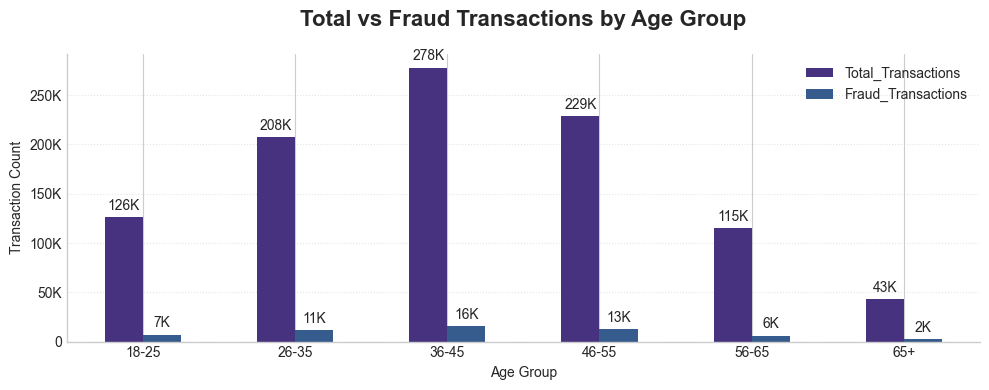

In [18]:
df['age_group'] = pd.cut(
    df['customer_age'], bins=[18,25,35,45,55,65,100],
    labels = ['18-25','26-35','36-45','46-55','56-65','65+'],
    include_lowest=True
)

age_analysis = (df.groupby('age_group').agg(
          Total_Transactions=('is_fraud', 'count'),
          Fraud_Transactions=('is_fraud', 'sum'),
          Fraud_Rate=('is_fraud', lambda x: round(x.mean()*100, 2))
      ).reset_index())

display(age_analysis)

fig, ax = plt.subplots(figsize=(10,4))
age_analysis.plot(x='age_group',y=['Total_Transactions', 'Fraud_Transactions'],kind='bar',ax=ax)
ax.set_title('Total vs Fraud Transactions by Age Group',fontsize=16,fontweight='bold',pad=20)
ax.set_xlabel('Age Group')
ax.set_ylabel('Transaction Count')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: format_func(x)))

# Bar labels
for container in ax.containers:
    labels = [format_func(v) for v in container.datavalues]
    ax.bar_label(container,labels=labels,padding=3)

ax.tick_params(axis='x', rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 2. Country Risk Ranking (Fraud Rate %)

,country,Total_transaction,Fraud_transaction,fraud_rate_pct
9,USA,299910,16617,5.54
5,India,120206,6600,5.49
8,UK,99677,5499,5.52
1,Brazil,80351,4552,5.67
4,Germany,79831,4424,5.54
2,Canada,69742,3879,5.56
6,Japan,70107,3845,5.48
3,France,69867,3785,5.42
7,Mexico,60275,3295,5.47
0,Australia,50034,2759,5.51


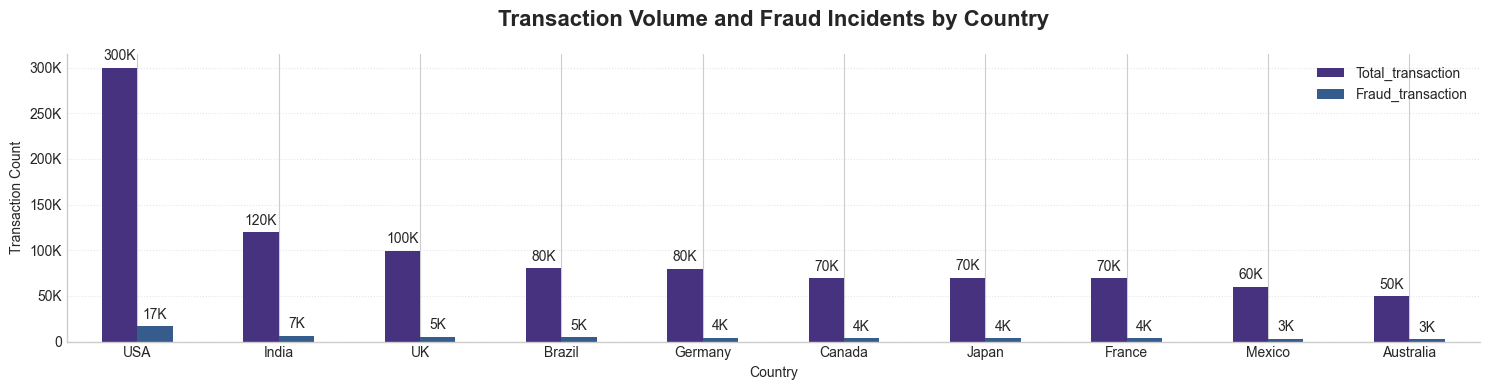

In [19]:
Country_risk = (df.groupby('country').agg(
    Total_transaction = ('is_fraud', 'count'), 
    Fraud_transaction = ('is_fraud', 'sum'), 
    fraud_rate_pct = ('is_fraud', lambda x: round(x.mean()*100, 2))
).reset_index().sort_values(by='Fraud_transaction', ascending=False))

display(Country_risk) 

fig, ax = plt.subplots(figsize=(15,4))
Country_risk.plot(x='country', y=['Total_transaction','Fraud_transaction'], ax=ax, kind='bar')
ax.set_title('Transaction Volume and Fraud Incidents by Country',fontsize=16,fontweight='bold',pad=20)
ax.set_xlabel('Country')
ax.set_ylabel('Transaction Count')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: format_func(x)))
# Bar labels
for container in ax.containers:
    labels = [format_func(v) for v in container.datavalues]
    ax.bar_label(container,labels=labels,padding=3)

ax.tick_params(axis='x', rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 7. Statistical Analysis Using SciPy

## 7.1 Descriptive Statistics

In [20]:
df[['transaction_amount','customer_age',
    'credit_score','distance_from_home_km',
    'failed_attempts','account_balance']].describe()

,transaction_amount,customer_age,credit_score,distance_from_home_km,failed_attempts,account_balance
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000
mean,204.724665,41.771678,679.028781,20.009890,0.380072,16594.25442
std,459.567802,13.424588,78.828748,20.011427,0.914603,28171.46068
min,1.000000,18.000000,300.000000,0.000000,0.000000,100.00000
25%,33.400000,32.000000,625.000000,5.800000,0.000000,3609.01750
50%,73.120000,42.000000,680.000000,13.900000,0.000000,8092.12000
75%,181.450000,51.000000,734.000000,27.700000,0.000000,18225.02500
max,46129.600000,85.000000,850.000000,292.100000,5.000000,500000.00000


## 7.2 Risk Factor Comparison: Fraud vs Legitimate Comparison

,Avg_Transaction_Amount,Avg_Distance_From_Home,Avg_Failed_Attempts,Avg_Credit_Score
Legitimate,203.36,20.01,0.35,679.13
Fraud,228.08,19.98,0.82,677.33


Avg_Failed_Attempts       134.29
Avg_Transaction_Amount     12.16
Avg_Distance_From_Home     -0.15
Avg_Credit_Score           -0.27
dtype: float64

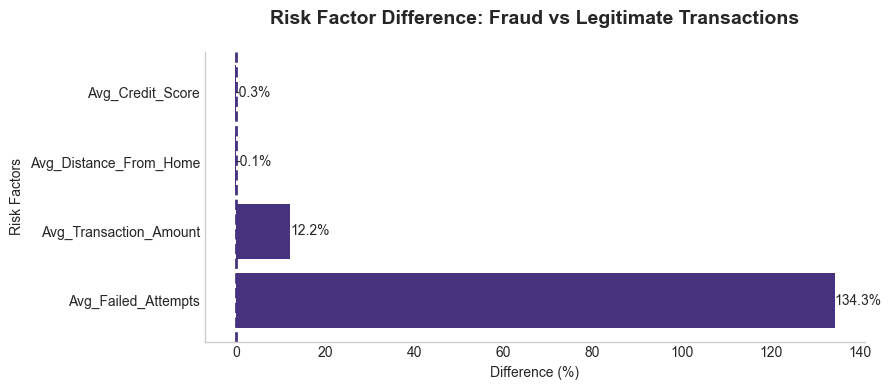

In [28]:
risk_comparison = (df.groupby('is_fraud').agg(
          Avg_Transaction_Amount=('transaction_amount', 'mean'),
          Avg_Distance_From_Home=('distance_from_home_km', 'mean'),
          Avg_Failed_Attempts=('failed_attempts', 'mean'),
          Avg_Credit_Score=('credit_score', 'mean')
      ).round(2))
risk_comparison.index = ['Legitimate', 'Fraud']
display(risk_comparison)

difference_pct = ((risk_comparison.loc['Fraud'] - risk_comparison.loc['Legitimate']) / risk_comparison.loc['Legitimate']) * 100
difference_pct = (difference_pct.round(2).sort_values(ascending=False))
display(difference_pct)

fig, ax = plt.subplots(figsize=(9,4))
bars = ax.barh(difference_pct.index,difference_pct.values)
ax.set_title('Risk Factor Difference: Fraud vs Legitimate Transactions',fontsize=14,fontweight='bold',pad=20)
ax.set_xlabel('Difference (%)')
ax.set_ylabel('Risk Factors')

# Reference line
ax.axvline(x=0,linestyle='--',linewidth=2)

# Labels
for bar in bars:
    width = bar.get_width()
    ax.text(width,bar.get_y() + bar.get_height()/2,f'{width:.1f}%',va='center',ha='left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

## 7.3 Hypothesis Testing

In [26]:
# Mann-Whitney U Test (Numerical Columns)
tests = {
    'Transaction Amount vs Fraud': 'transaction_amount',
    'Failed Attempts vs Fraud': 'failed_attempts',
    'Distance From Home vs Fraud': 'distance_from_home_km',
    'Credit Score vs Fraud': 'credit_score'
}

for title, column in tests.items():

    fraud = df[df['is_fraud'] == 1][column]
    legit = df[df['is_fraud'] == 0][column]

    u_stat, p_value = mannwhitneyu(
        fraud,
        legit,
        alternative='two-sided'
    )

    print('=' * 60)
    print(title)
    print('=' * 60)
    print(f'U Statistic: {u_stat:.2f}')
    print(f'P-value: {p_value:.6f}')

    if p_value < 0.05:
        print('Decision: Reject H₀')
        print('Conclusion: Significant difference found.\n')
    else:
        print('Decision: Fail to Reject H₀')
        print('Conclusion: No significant difference found.\n')

Transaction Amount vs Fraud
U Statistic: 26611541613.00
P-value: 0.000000
Decision: Reject H₀
Conclusion: Significant difference found.

Failed Attempts vs Fraud
U Statistic: 30638577121.00
P-value: 0.000000
Decision: Reject H₀
Conclusion: Significant difference found.

Distance From Home vs Fraud
U Statistic: 26131623977.00
P-value: 0.641799
Decision: Fail to Reject H₀
Conclusion: No significant difference found.

Credit Score vs Fraud
U Statistic: 25830324469.00
P-value: 0.000041
Decision: Reject H₀
Conclusion: Significant difference found.



## 7.4 Correlation Analysis

,transaction_amount,customer_age,credit_score,failed_attempts,time_since_last_txn_hrs,is_fraud
transaction_amount,1.000000,-0.002210,-0.000795,0.000765,0.000843,0.012290
customer_age,-0.002210,1.000000,0.000100,-0.000026,-0.000373,-0.002966
credit_score,-0.000795,0.000100,1.000000,0.000184,0.001068,-0.005224
failed_attempts,0.000765,-0.000026,0.000184,1.000000,-0.001188,0.116541
time_since_last_txn_hrs,0.000843,-0.000373,0.001068,-0.001188,1.000000,-0.008909
is_fraud,0.012290,-0.002966,-0.005224,0.116541,-0.008909,1.000000


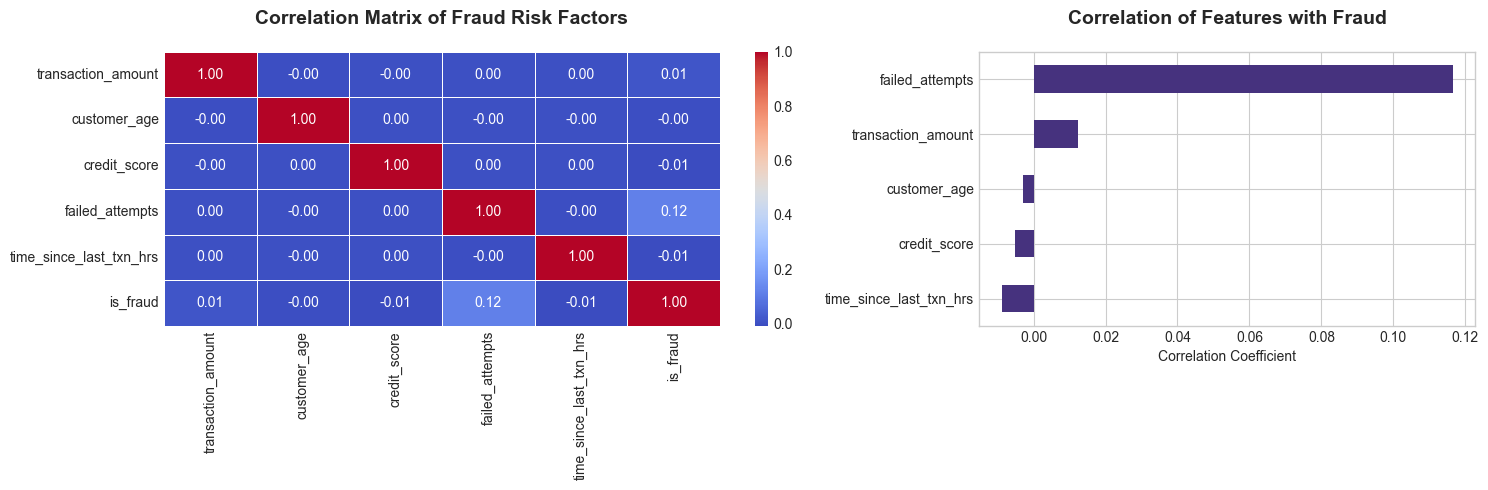

In [38]:
corr_cols = ['transaction_amount','customer_age','credit_score','failed_attempts','time_since_last_txn_hrs','is_fraud']
corr_matrix = df[corr_cols].corr()
display(corr_matrix)

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(15,5), gridspec_kw={'width_ratios':[1.4,1]})

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax = ax1)
ax1.set_title('Correlation Matrix of Fraud Risk Factors',fontsize=14,fontweight='bold',pad=20)

fraud_corr = (corr_matrix['is_fraud'].drop('is_fraud').sort_values())
fraud_corr.plot(kind='barh',ax = ax2)
ax2.set_title('Correlation of Features with Fraud', fontsize=14,fontweight='bold',pad=20)
ax2.set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

# 8. Key Business Insights

### Insight 1: Transaction Amount is a Significant Fraud Indicator

The Mann-Whitney U Test revealed a statistically significant difference in transaction amounts between fraudulent and legitimate transactions (p < 0.05). This indicates that transaction amount is a key factor associated with fraudulent activity and should be considered during fraud risk assessment.

### Insight 2: Failed Authentication Attempts are Strongly Associated with Fraud

Fraudulent transactions exhibited significantly different failed authentication attempt patterns compared to legitimate transactions. This suggests that repeated authentication failures may serve as a strong warning signal of potential fraud.

### Insight 3: Transaction Timing Influences Fraud Behavior

Analysis of transaction intervals showed meaningful differences in fraud occurrence across various transaction gap categories. Unusual transaction timing patterns may indicate suspicious account activity.

### Insight 4: Payment Method Influences Fraud Risk

Fraud rates varied across payment methods, indicating that certain payment channels are more vulnerable to fraudulent activity than others. Payment-specific monitoring can improve fraud detection effectiveness.

### Insight 5: Fraud Risk Differs Across Merchant Categories

Merchant category analysis revealed noticeable differences in fraud rates among business sectors. This finding highlights the importance of category-specific fraud prevention strategies.

### Insight 6: International Transactions Carry Higher Fraud Risk

International transactions demonstrated a higher fraud rate compared to domestic transactions, suggesting increased exposure to fraudulent activities in cross-border payment environments.

### Insight 7: Customer Age Has Limited Impact on Fraud Occurrence

Fraud rates remained relatively similar across different age groups, indicating that customer age alone is not a strong predictor of fraudulent behavior.

### Insight 8: Behavioral Factors are More Important than Demographic Factors

The overall analysis suggests that behavioral indicators such as transaction amount, failed authentication attempts, and transaction timing have a stronger relationship with fraud occurrence than demographic attributes such as customer age.


# 9. Conclusion

This project analyzed one million banking transactions to identify fraud patterns and understand the key factors associated with fraudulent activity. Through exploratory data analysis, statistical analysis, and visualization techniques, several important insights were discovered regarding transaction behavior, customer characteristics, and fraud risk factors.

The analysis revealed that transaction amount and failed authentication attempts are among the strongest indicators of fraudulent activity. Statistical hypothesis testing confirmed that these factors differ significantly between fraudulent and legitimate transactions. In contrast, customer age and certain demographic attributes showed limited influence on fraud occurrence, suggesting that behavioral patterns are more useful for fraud detection than demographic characteristics.

The study also found that fraud risk varies across payment methods, merchant categories, and transaction types. Additionally, international transactions demonstrated a higher fraud risk compared to domestic transactions, highlighting the importance of enhanced monitoring for cross-border payments.

Overall, the findings suggest that effective fraud detection strategies should prioritize behavioral indicators such as transaction amount, authentication failures, and transaction timing patterns. These insights can help financial institutions strengthen fraud prevention mechanisms, improve transaction monitoring systems, and reduce financial losses caused by fraudulent activities.

This project demonstrates how data analysis, statistical testing, and visualization techniques can be applied to uncover meaningful fraud patterns and support data-driven decision-making in the banking and financial services industry.


# 10. Future Scope

While this project focused on exploratory data analysis and statistical analysis, future work can extend the study by implementing machine learning and anomaly detection techniques for automated fraud prediction. Advanced models such as Logistic Regression, Random Forest, XGBoost, and Isolation Forest can be used to identify suspicious transactions in real time.

Additionally, integrating real-world transaction data, customer behavior tracking, and network-based fraud detection methods could further improve fraud detection accuracy. Developing interactive dashboards and real-time monitoring systems would also help financial institutions proactively identify and prevent fraudulent activities.

The insights generated in this project provide a strong analytical foundation for building more advanced fraud detection and risk management solutions in the banking and financial services sector.
